# ECDF rare-event threshold analysis

Uses `mfpt_all_thresholds-new-ref.pkl` to find thresholds that best fit an exponential rare-event model.


In [71]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats
import seaborn as sns

from common.consts import long_to_short, proteins
from paper.style_utils import set_paper_style
from common.utils import estimateMFPT
set_paper_style()

plt.rcParams['figure.dpi'] = 160

k = 10


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [72]:
data_dir = repo_root / 'data'
mfpt_grid_pkl = data_dir / 'mfpt_all_thresholds-new-ref.pkl'
mfpt_raw_pkl = data_dir / 'mfpt-pace=25000-new-ref.pkl'

mfpt_tables = pd.read_pickle(mfpt_grid_pkl)
all_mfpt = pd.read_pickle(mfpt_raw_pkl)
thresholds = sorted(mfpt_tables.keys(), key=float)

names = list(proteins)


In [73]:
# Keep thresholds with samples for all names (avoid empty inputs)
thresholds = [
    thr for thr in thresholds
    if all(len(all_mfpt[name][thr]) >= 10 for name in names)
]

for name in names: 
    for thr in thresholds:
        if (len(all_mfpt[name][thr]) < 200):
            print(long_to_short[name], name, thr, len(all_mfpt[name][thr]))
        # print(len(all_mfpt[name][thr]))

D2R YYRPETGTWY 0.28 87
D2R YYRPETGTWY 0.3 63
D2R YYRPETGTWY 0.32 42
D2R YYRPETGTWY 0.34 29
D2R YYRPETGTWY 0.36 20
D2R YYRPETGTWY 0.38 16
D2R YYRPETGTWY 0.4 13
D2R YYRPETGTWY 0.42 11
Y9Q YYDPETGTWQ 0.28 121
Y9Q YYDPETGTWQ 0.3 99
Y9Q YYDPETGTWQ 0.32 77
Y9Q YYDPETGTWQ 0.34 56
Y9Q YYDPETGTWQ 0.36 47
Y9Q YYDPETGTWQ 0.38 37
Y9Q YYDPETGTWQ 0.4 33
Y9Q YYDPETGTWQ 0.42 28
T5R YYDPERGTWY 0.3 199
T5R YYDPERGTWY 0.32 199
T5R YYDPERGTWY 0.34 199
T5R YYDPERGTWY 0.36 199
T5R YYDPERGTWY 0.38 199
T5R YYDPERGTWY 0.4 199
T5R YYDPERGTWY 0.42 199
T5G YYDPEGGTWY 0.4 199
T5G YYDPEGGTWY 0.42 199


In [74]:
def fit_exp_ecdf_stats(samples):
    x = np.array(samples, float)
    x = x[np.isfinite(x)]
    if x.size < 3:
        return np.nan, np.nan, np.nan
    x.sort()
    n = x.size
    def F(t, tau):
        return 1 - np.exp(-t / tau)
    ecdf = np.arange(1, n + 1) / n
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    D, p = stats.kstest(x, 'expon', args=(0, tau))
    return float(tau), float(D), float(p)


def stats_for_threshold(all_mfpt, names, thr):
    rows = []
    for name in names:
        samples = np.array(all_mfpt[name][thr], float)
        samples = samples[np.isfinite(samples)]
        samples.sort()
        _, k_dyn = estimateMFPT(samples, k)
        s = samples[:k_dyn]

        tau, D, p = fit_exp_ecdf_stats(s)
        rows.append({'name': name, 'n': int(s.size), 'tau': tau, 'D': D, 'p': p})
    return pd.DataFrame(rows)


In [75]:
k_fixed = 25

summary_rows = []
per_threshold = {}

for thr in thresholds:
    df = stats_for_threshold(all_mfpt, names, thr)
    per_threshold[thr] = df
    summary_rows.append({
        'threshold': float(thr),
        'median_D': df['D'].median(),
        'median_p': df['p'].median(),
        'frac_p_gt_0_05': (df['p'] > 0.05).mean(),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('threshold')
summary_df


,threshold,median_D,median_p,frac_p_gt_0_05
0,0.28,0.162185,0.389024,0.888889
1,0.30,0.162812,0.429651,0.972222
2,0.32,0.176775,0.361550,1.000000
3,0.34,0.163150,0.407178,1.000000
4,0.36,0.167408,0.463871,0.972222
5,0.38,0.172611,0.502678,1.000000
6,0.40,0.169790,0.508335,1.000000
7,0.42,0.169833,0.480154,1.000000


In [76]:
best_by_D = summary_df.loc[summary_df['median_D'].idxmin()]
best_by_p = summary_df.loc[summary_df['median_p'].idxmax()]

print(f"Best by median D: thr={best_by_D['threshold']:.3f}, D={best_by_D['median_D']:.3g}, p_med={best_by_D['median_p']:.3g}")
print(f"Best by median p: thr={best_by_p['threshold']:.3f}, p_med={best_by_p['median_p']:.3g}, D_med={best_by_p['median_D']:.3g}")


Best by median D: thr=0.280, D=0.162, p_med=0.389
Best by median p: thr=0.400, p_med=0.508, D_med=0.17


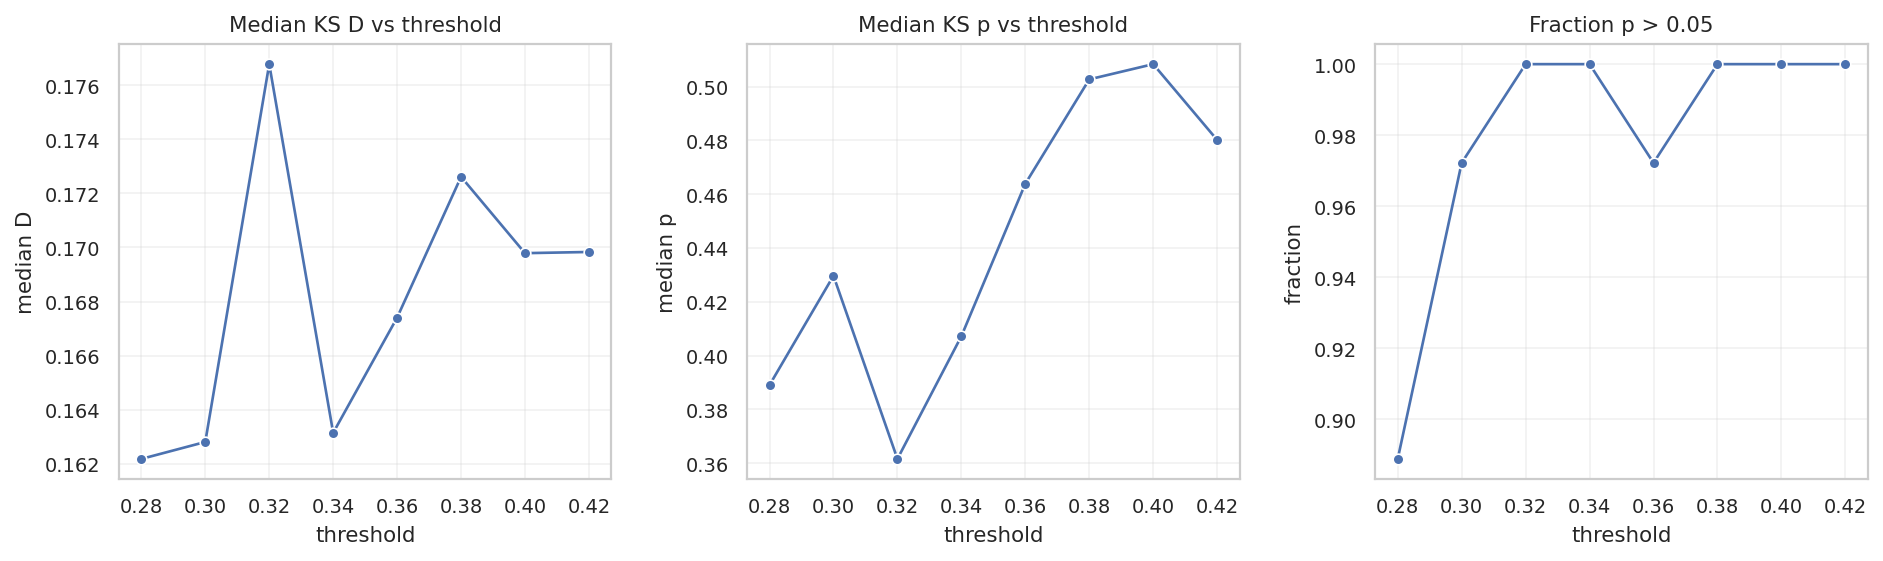

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), squeeze=False)

sns.lineplot(data=summary_df, x='threshold', y='median_D', marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Median KS D vs threshold')
axes[0, 0].set_xlabel('threshold')
axes[0, 0].set_ylabel('median D')
axes[0, 0].grid(True, alpha=0.25)

sns.lineplot(data=summary_df, x='threshold', y='median_p', marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Median KS p vs threshold')
axes[0, 1].set_xlabel('threshold')
axes[0, 1].set_ylabel('median p')
axes[0, 1].grid(True, alpha=0.25)

sns.lineplot(data=summary_df, x='threshold', y='frac_p_gt_0_05', marker='o', ax=axes[0, 2])
axes[0, 2].set_title('Fraction p > 0.05')
axes[0, 2].set_xlabel('threshold')
axes[0, 2].set_ylabel('fraction')
axes[0, 2].grid(True, alpha=0.25)

fig.tight_layout()
plt.show()


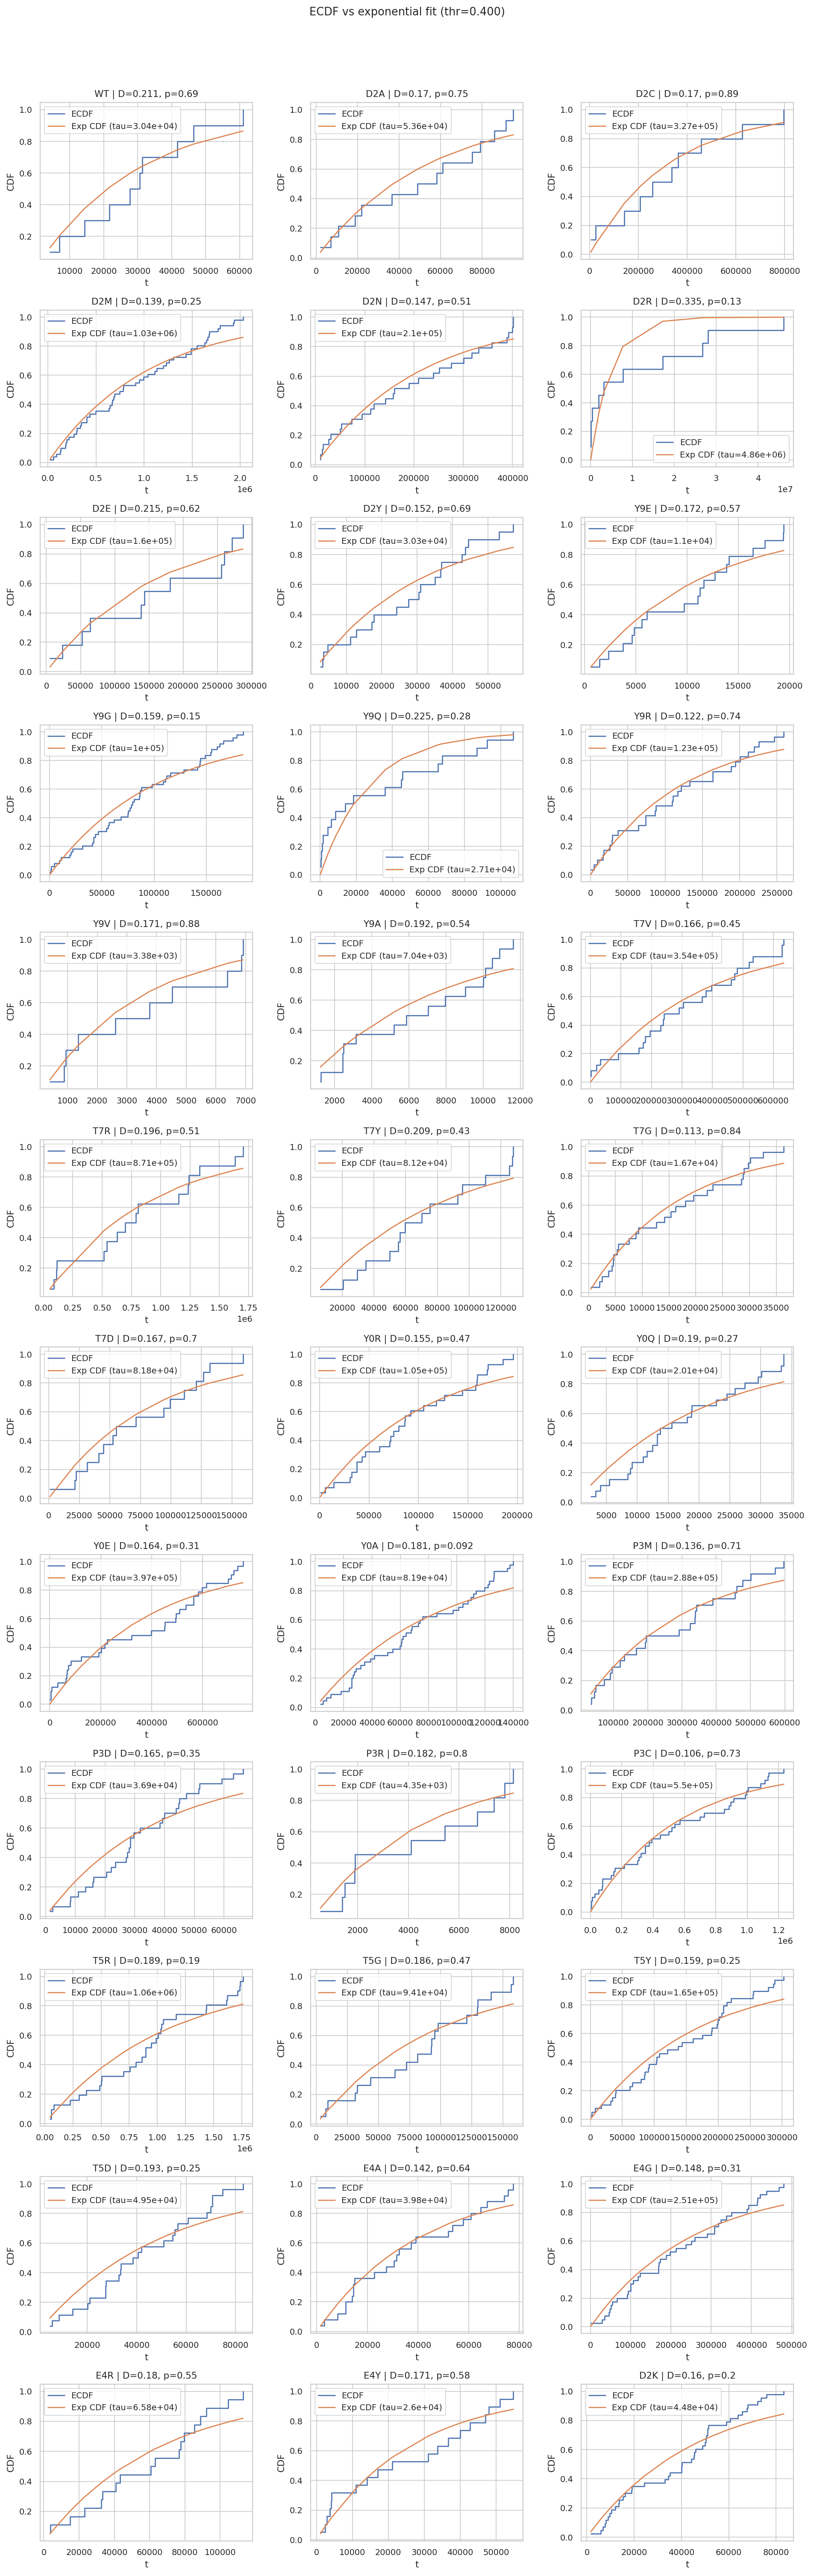

In [78]:
# ECDF grid for the best-by-median-D threshold
th_ecdf = float(best_by_p['threshold'])

ncols = 3
m = len(names)
nrows = int(np.ceil(m / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows), squeeze=False)

for i, name in enumerate(names):
    r, c = divmod(i, ncols)
    samples = np.array(all_mfpt[name][th_ecdf], float)
    samples = samples[np.isfinite(samples)]
    samples.sort()
    _, k_dyn = estimateMFPT(samples, k)
    s = samples[:k_dyn]
 

    x = s
    n = x.size
    ecdf = np.arange(1, n + 1) / n
    def F(t, tau):
        return 1 - np.exp(-t / tau)
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    th = stats.expon.cdf(x, scale=tau)
    D, p = stats.kstest(x, 'expon', args=(0, tau))

    ax = axes[r, c]
    ax.step(x, ecdf, where='post', label='ECDF')
    ax.plot(x, th, label=f"Exp CDF (tau={tau:.3g})")
    ax.set_title(f"{long_to_short[name]} | D={D:.3g}, p={p:.2g}")
    ax.set_xlabel('t')
    ax.set_ylabel('CDF')
    ax.legend()

for ax in axes.ravel()[m:]:
    ax.axis('off')

fig.suptitle(f"ECDF vs exponential fit (thr={th_ecdf:.3f})")
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
